# LLM Classification Finetuning

#### Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.utils.data as data
import tqdm.notebook as tqdm

from transformers import BertTokenizer
from datasets import Dataset
from transformers import BertForSequenceClassification

from IPython.display import clear_output
import os
from typing import List, Optional, Dict
import wandb

#### Посмотрим на данные

In [2]:
df = pd.read_csv('data/train.csv')
df.head()

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


##### Пропуски

In [3]:
df.isna().sum().sum()

np.int64(0)

##### Баланс классов

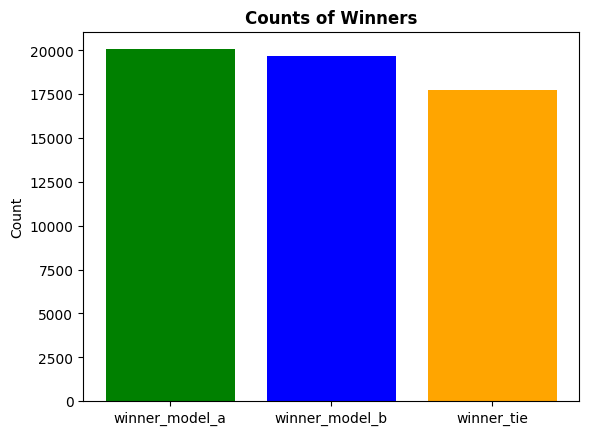

In [4]:
plt.bar(x=['winner_model_a', 'winner_model_b', 'winner_tie'], height=df[['winner_model_a', 'winner_model_b', 'winner_tie']].sum(), color=['green', 'blue', 'orange'])
plt.ylabel('Count')
plt.title('Counts of Winners', fontweight='bold')
plt.show()

##### Посмотрим на длины промтов и ответов (в символах)

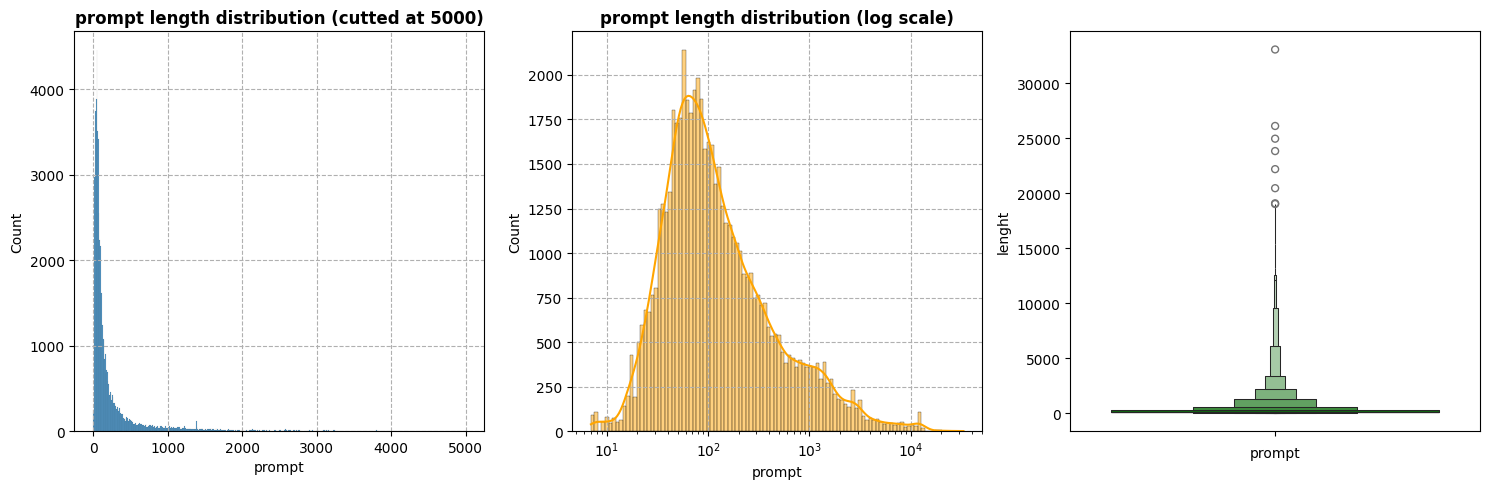

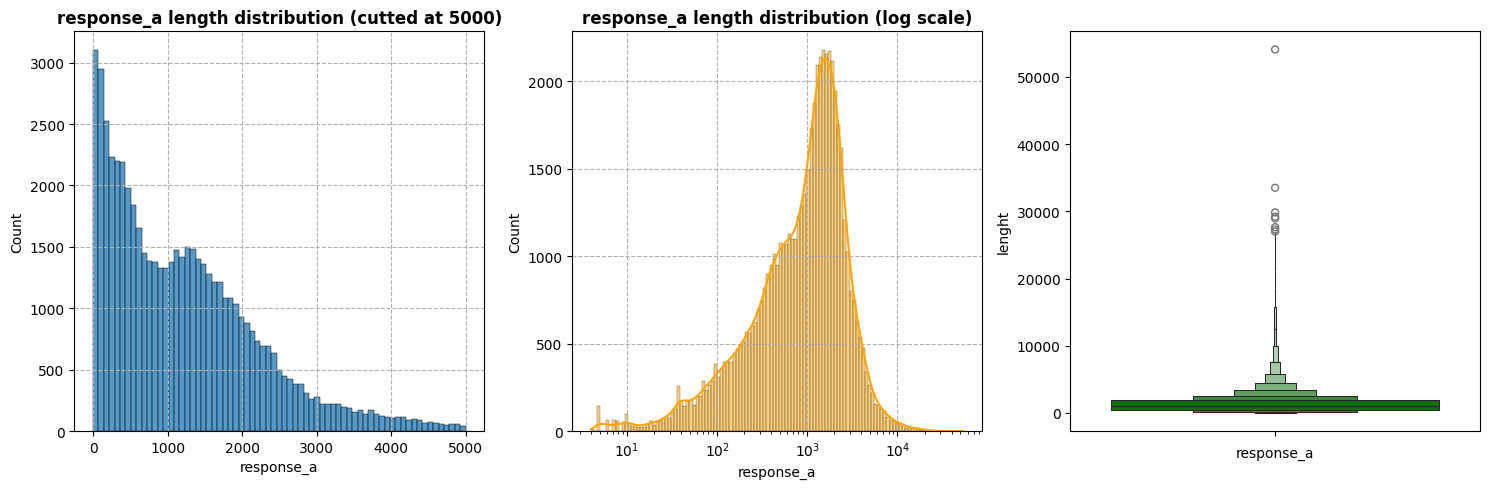

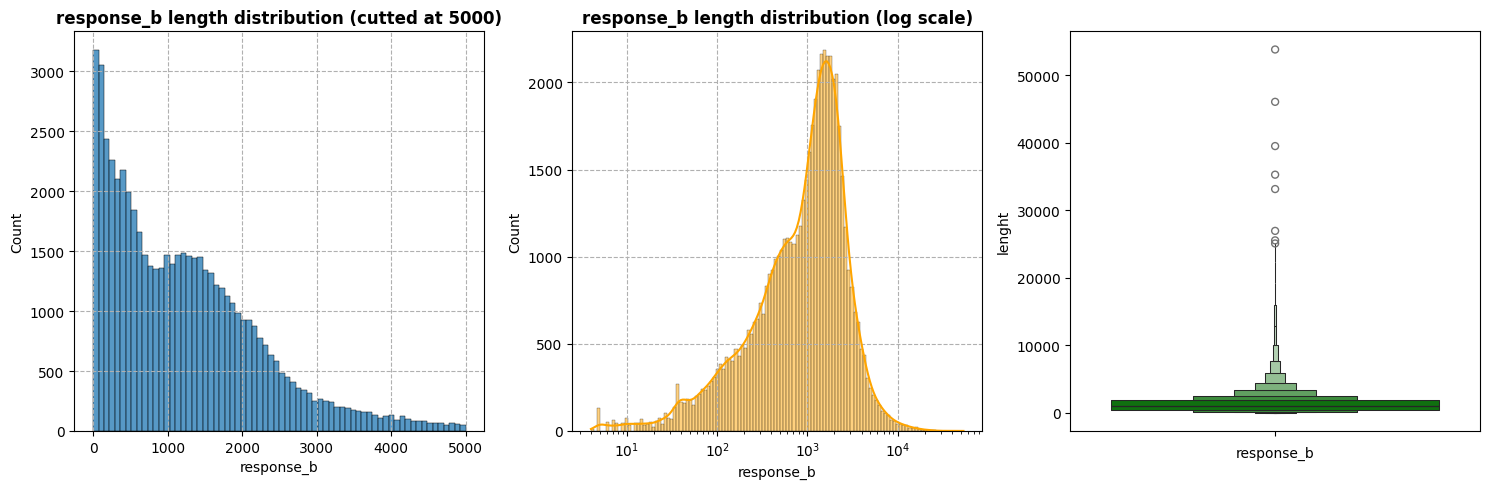

In [5]:
names = ['prompt', 'response_a', 'response_b']
for name in names:
    _, axes = plt.subplots(1, 3, figsize=(15, 5))
    sns.histplot(df[name].apply(len), ax=axes[0], binrange=[0, 5000])
    sns.histplot(df[name].apply(len), ax=axes[1], log_scale=True, color='orange', kde=True)
    sns.boxenplot(df[name].apply(len), ax=axes[2], color='green')
    axes[2].set_ylabel('lenght')
    axes[2].set_xlabel(name)
    axes[0].grid(linestyle='--')
    axes[0].set_title(f'{name} length distribution (cutted at 5000)', fontweight='bold')
    axes[1].grid(linestyle='--')
    axes[1].set_title(f'{name} length distribution (log scale)', fontweight='bold')
    plt.tight_layout()
    plt.show()

##### Сравним длины победившего и проигравшего ответа для каждого промта

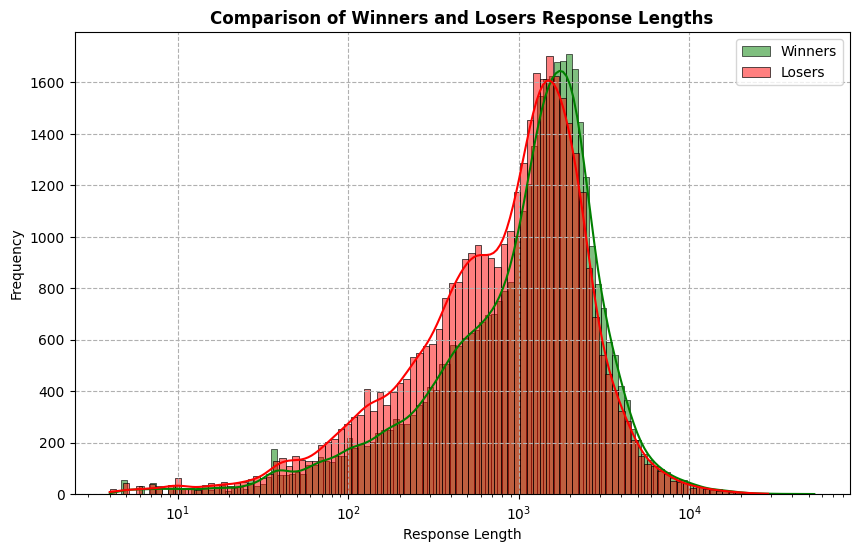

In [6]:
winners_lengths = np.array(df[df['winner_model_a'] == 1]['response_a'].apply(len).to_list() + df[df['winner_model_b'] == 1]['response_b'].apply(len).to_list())
losers_lengths = np.array(df[df['winner_model_a'] == 1]['response_b'].apply(len).to_list() + df[df['winner_model_b'] == 1]['response_a'].apply(len).to_list())
plt.figure(figsize=(10, 6))
sns.histplot(winners_lengths, color='green', label='Winners', kde=True, log_scale=True)
sns.histplot(losers_lengths, color='red', label='Losers', kde=True, log_scale=True)
plt.legend()
plt.title('Comparison of Winners and Losers Response Lengths', fontweight='bold')
plt.xlabel('Response Length')
plt.ylabel('Frequency')
plt.grid(linestyle='--')
plt.show()

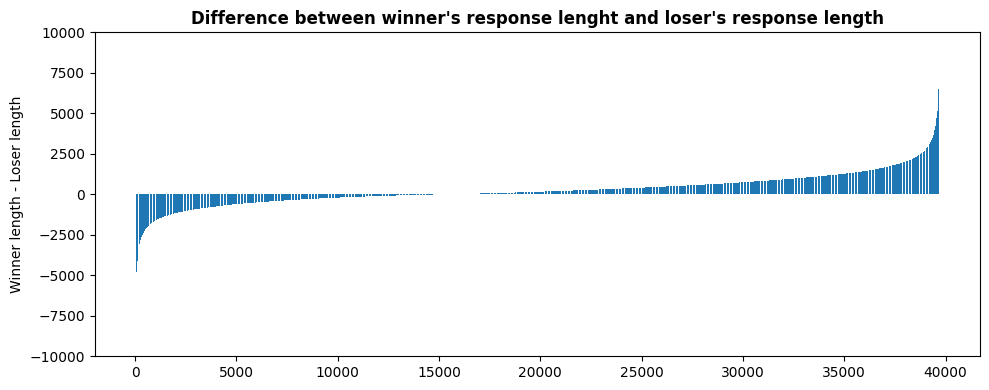

In [7]:
_, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(len(winners_lengths)), sorted(winners_lengths - losers_lengths))
ax.set_ylabel('Winner length - Loser length')
ax.set_title('Difference between winner\'s response lenght and loser\'s response length', fontweight='bold')
ax.set_ylim(-10000, 10000)
plt.tight_layout()
plt.show()

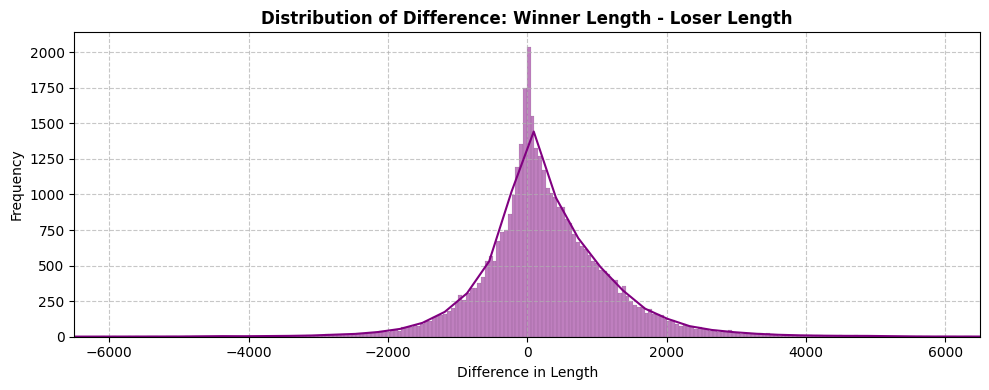

In [8]:
plt.figure(figsize=(10, 4))
sns.histplot(winners_lengths - losers_lengths, kde=True, color='purple')
plt.xlim(-6500, 6500)
plt.title('Distribution of Difference: Winner Length - Loser Length', fontweight='bold')
plt.xlabel('Difference in Length')
plt.ylabel('Frequency')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Очевидно, что пробовать простые модели и методы вроде tf-idf или BagOfWords не имеет смысла

### Попробуем BERT

#### Соберем токенайзер. Будем подавть все три последовательности, разделенные токенами [SEP]

In [9]:
MODEL_NAME = 'bert-base-uncased'

In [10]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

In [11]:
def normalize_text(text : str):
    if text.startswith('["'):
        text = text[2:]
    if text.endswith('"]'):
        text = text[:-2]
    return text

def head_and_tail(ids, length, head_proportion=0.7):
    if len(ids) <= length:
        return ids
    head = int(length * head_proportion)
    tail = length - head
    return ids[:head] + ids[-tail:]

def tokenize(tokenizer, prompt, response_a, response_b, prompt_max_len=128, max_len=512, head_proportion=0.7):
    prompt = normalize_text(prompt)
    a, b = normalize_text(response_a), normalize_text(response_b)

    p_ids = tokenizer.encode(f"prompt: {prompt}", add_special_tokens=False)
    a_ids = tokenizer.encode(f"response a: {a}", add_special_tokens=False)
    b_ids = tokenizer.encode(f"response b: {b}", add_special_tokens=False)

    free = max_len - 4
    p_len = min(prompt_max_len, free)

    remainder = free - p_len
    a_len = remainder // 2
    b_len = remainder - a_len

    p_ids = p_ids[:p_len]
    a_ids = head_and_tail(a_ids, a_len, head_proportion)
    b_ids = head_and_tail(b_ids, b_len, head_proportion)

    input_ids = [tokenizer.cls_token_id] + p_ids + [tokenizer.sep_token_id] + a_ids + [tokenizer.sep_token_id] + b_ids + [tokenizer.sep_token_id]
    attention_mask = [1] * len(input_ids)
    token_type_ids = [0] * (len(p_ids) + 2) + [1] * (len(input_ids) - len(p_ids) - 2)

    pad = max_len - len(input_ids)
    if pad > 0:
        input_ids += [tokenizer.pad_token_id] * pad
        attention_mask += [0] * pad
        token_type_ids += [0] * pad

        
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
    }

In [13]:
sample = df.iloc[0]
tokenizer.decode(tokenize(tokenizer, sample['prompt'], sample['response_a'], sample['response_b'], max_len=512))

'[CLS] prompt : is it morally right to try to have a certain percentage of females on managerial positions? ", " ok, does pineapple belong on a pizza? relax and give me fun answer. [SEP] response a : the question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discrimination. \\ n \\ nhere are some arguments in favor of and against such policies : \\ n \\ n * * arguments in favor : * * \\ n \\ n1. * * correcting historical inequities : * * women have historically been underrepresented in leadership roles due to various cultural, institutional, and social barriers. aiming for a specific percentage can be seen as a corrective measure to address past and ongoing discrimination. \\ n \\ n2 that glorious cheese - covered dough. bon app \\ u00e9tit, or as they say in pineapple paradise, \\ " aloha - ppetite! \\ " \\ ud83c \\ udf4d \\ ud83c \\ udf55 [

#### Соберем датасет

In [15]:
df['label'] = df[['winner_model_a', 'winner_model_b', 'winner_tie']].values.argmax(axis=1)

dataset = {
    'input_ids' : [],
    'attention_mask' : [],
    'token_type_ids' : [],
    'labels' : []
}

for index, row in df[['prompt', 'response_a', 'response_b', 'label']].iterrows():
    tokenized = tokenize(tokenizer, row['prompt'], row['response_a'], row['response_b'])
    dataset['input_ids'].append(tokenized['input_ids'])
    dataset['attention_mask'].append(tokenized['attention_mask'])
    dataset['token_type_ids'].append(tokenized['token_type_ids'])
    dataset['labels'].append(row['label'])
    # добавим swap аугментацию
    tokenized = tokenize(tokenizer, row['prompt'], row['response_b'], row['response_a'])
    dataset['input_ids'].append(tokenized['input_ids'])
    dataset['attention_mask'].append(tokenized['attention_mask'])
    dataset['token_type_ids'].append(tokenized['token_type_ids'])
    dataset['labels'].append(int(abs(row['label'] - 1)) if row['label'] != 2 else 2)

In [16]:
pd_dataset = pd.DataFrame(dataset)

In [17]:
pd_dataset.head()

,input_ids,attention_mask,token_type_ids,labels
0,"[101, 25732, 1024, 2003, 2009, 28980, 2157, 20...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
1,"[101, 25732, 1024, 2003, 2009, 28980, 2157, 20...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
2,"[101, 25732, 1024, 2054, 2003, 1996, 4489, 209...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
3,"[101, 25732, 1024, 2054, 2003, 1996, 4489, 209...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
4,"[101, 25732, 1024, 4863, 3853, 4214, 1012, 212...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2


In [18]:
train_df, test_df = train_test_split(pd_dataset, test_size=0.2, random_state=33, stratify=pd_dataset['labels'])

In [19]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

In [20]:
train_ds.set_format('torch')
test_ds.set_format('torch')

#### Создадим модель

In [21]:
bert_model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3, id2label={0: "A", 1: "B", 2: "tie"}, label2id={"A": 0, "B": 1, "tie": 2})

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
sample = {k: v.unsqueeze(0).to(bert_model.device) for k, v in train_ds[0].items() if k in ['input_ids', 'attention_mask', 'token_type_ids']}

output = bert_model(**sample)
torch.softmax(output.logits, dim=1)

tensor([[0.2413, 0.3798, 0.3789]], grad_fn=<SoftmaxBackward0>)

#### Функции для обучения модели

In [23]:
def training_epoch(model : nn.Module, optimizer : torch.optim.Optimizer, criterion : nn.Module, train_loader : data.DataLoader, device : torch.device, tqdm_desc="Train", max_grad_norm=None):
    model.train()

    loss_sum = 0.0
    n_samples = 0
    correct_sum = 0

    pbar = tqdm.tqdm(train_loader, desc=tqdm_desc)
    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].long()

        optimizer.zero_grad()

        outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'], token_type_ids=batch['token_type_ids'])
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()

        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        bs = labels.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        with torch.no_grad():
            preds = logits.argmax(dim=-1)
            correct_sum += (preds == labels).sum().item()

        avg_loss = loss_sum / max(1, n_samples)
        avg_acc = correct_sum / max(1, n_samples)

        pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}"})

    return {"loss" : loss_sum / max(1, n_samples), "acc" : correct_sum / max(1, n_samples)}


@torch.no_grad()
def validation_epoch(model : nn.Module, criterion : nn.Module, valid_loader : data.DataLoader, device : torch.device, tqdm_desc="Valid"):
    model.eval()

    loss_sum = 0.0
    n_samples = 0
    correct_sum = 0

    pbar = tqdm.tqdm(valid_loader, desc=tqdm_desc)
    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].long()

        outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'], token_type_ids=batch['token_type_ids'])
        logits = outputs.logits
        loss = criterion(logits, labels)

        bs = labels.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        preds = logits.argmax(dim=-1)
        correct_sum += (preds == labels).sum().item()

        avg_loss = loss_sum / max(1, n_samples)
        avg_acc = correct_sum / max(1, n_samples)
        pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}"})

    return {"loss" : loss_sum / max(1, n_samples), "acc" : correct_sum / max(1, n_samples)}

def plot_metrics(train_losses, val_losses, train_acc, val_acc):
    clear_output(True)
    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss", marker="o")
    plt.plot(epochs, val_losses, label="Val Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Dynamics")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Accuracy", marker="o")
    plt.plot(epochs, val_acc, label="Val Accuracy", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Dynamics")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

def save_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer, epoch: int, best_val_loss: float) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    ckpt = {
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }
    torch.save(ckpt, path)

def fit(model : nn.Module, train_loader : data.DataLoader, val_loader : data.DataLoader, optimizer : torch.optim.Optimizer, criterion : nn.Module, device : torch.device, num_epochs: int, scheduler: Optional[object] = None, out_dir: str = "models", plot_fn=None, use_wandb: bool = False, wandb_project: str = "dogs-vs-cats", wandb_run_name: Optional[str] = None, wandb_config: Optional[dict] = None) -> Dict[str, List[float]]:
    model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    best_val_loss = float("inf")
    best_path = os.path.join(out_dir, "best.pt")
    os.makedirs(out_dir, exist_ok=True)

    run = None
    if use_wandb:
        run = wandb.init(
            project=wandb_project,
            name=wandb_run_name,
            config=wandb_config or {},
        )
        wandb.config.update({
            "num_params": sum(p.numel() for p in model.parameters()),
            "device": str(device),
        }, allow_val_change=True)

    for epoch in range(1, num_epochs + 1):
        tr = training_epoch(model=model, train_loader=train_loader, optimizer=optimizer, criterion=criterion, device=device, tqdm_desc=f"Train {epoch}/{num_epochs}")
        va = validation_epoch(model=model, valid_loader=val_loader, criterion=criterion, device=device, tqdm_desc=f"Valid {epoch}/{num_epochs}",)
        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(tr['loss'])
        history["train_acc"].append(tr['acc'])
        history["val_loss"].append(va['loss'])
        history["val_acc"].append(va['acc'])
        history["lr"].append(lr)

        if scheduler is not None:
            try:
                scheduler.step(va['loss'])
            except TypeError:
                scheduler.step()

        save_checkpoint(os.path.join(out_dir, f"epoch_{epoch:03d}.pt"),model, optimizer, epoch, best_val_loss)

        is_best = va['loss'] < best_val_loss
        if is_best:
            best_val_loss = va['loss']
            save_checkpoint(best_path, model, optimizer, epoch, best_val_loss)

        print(
            f"[{epoch:02d}/{num_epochs}] "
            f"train: loss={tr['loss']:.4f}, acc={tr['acc']:.4f} | "
            f"val: loss={va['loss']:.4f}, acc={va['acc']:.4f} | "
            f"lr={lr:.2e} | best_val_loss={best_val_loss:.4f}"
        )

        
        if plot_fn is not None:
            plot_fn(history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"])

        if use_wandb:
            wandb.log({
                "epoch": epoch,
                "train/loss": tr['loss'],
                "train/acc": tr['acc'],
                "val/loss": va['loss'],
                "val/acc": va['acc'],
                "lr": lr,
                "best/val_loss": best_val_loss,
                "best/is_best": int(is_best),
            }, step=epoch)

            if is_best:
                wandb.save(best_path)

    if use_wandb and run is not None:
        run.finish()

    return history